In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)  # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


In [5]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)  # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)


Running on: cpu


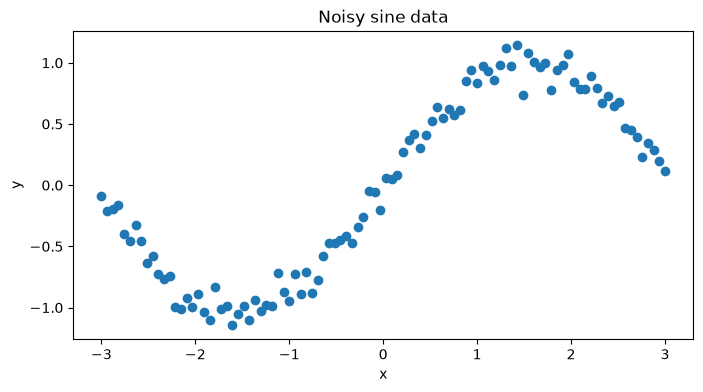

Final weight: 0.3390271203787366
Final bias: -0.017600294515841334
Final loss: 0.19550600956143946


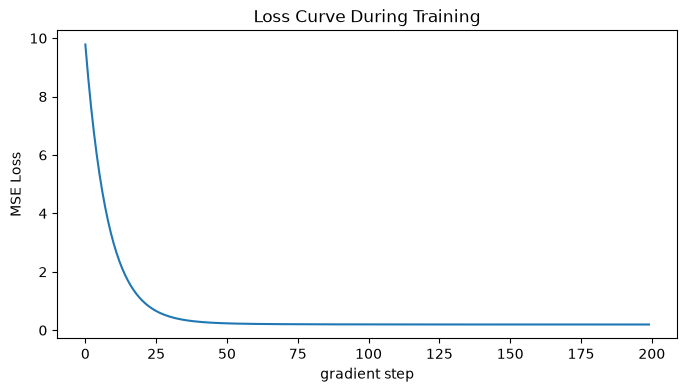

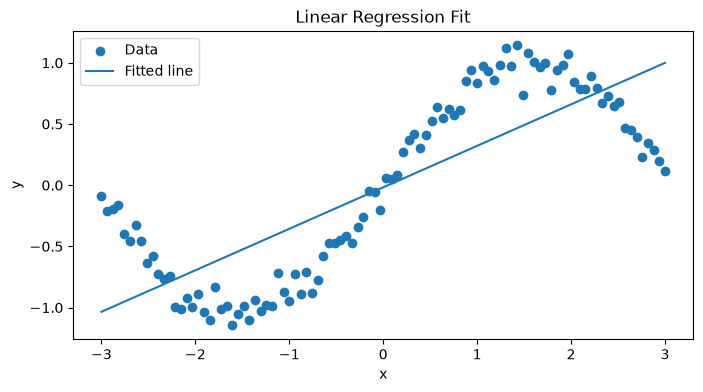

In [6]:
# Generate toy data
x = np.linspace(-3, 3, 100)

noise = np.random.normal(0, 0.1, 100)
y = np.sin(x) + noise

# Plot data
plt.figure(figsize=(8, 4))
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Noisy sine data")
plt.show()


# Initialize parameters
w = np.random.randn()
b = np.random.randn()

# Training settings
lr = 0.01
n_steps = 200

losses = []

# Gradient descent loop
for i in range(n_steps):
    # Prediction
    y_hat = w * x + b

    # Loss (MSE)
    loss = np.mean((y_hat - y) ** 2)

    # Gradients
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    # Updating parameters
    w -= lr * dw
    b -= lr * db

    # Record loss
    losses.append(loss)

print("Final weight:", w)
print("Final bias:", b)
print("Final loss:", loss)

# Plot loss curve

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("gradient step")
plt.ylabel("MSE Loss")
plt.title("Loss Curve During Training")
plt.show()

# Plot fitted line with data

plt.figure(figsize=(8, 4))

plt.scatter(x, y, label="Data")

# fitted line
y_pred = w * x + b
plt.plot(x, y_pred, label="Fitted line")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()

x shape: (100, 1)
y shape: (100, 1)
Final loss with tanh: 0.023476316517891917


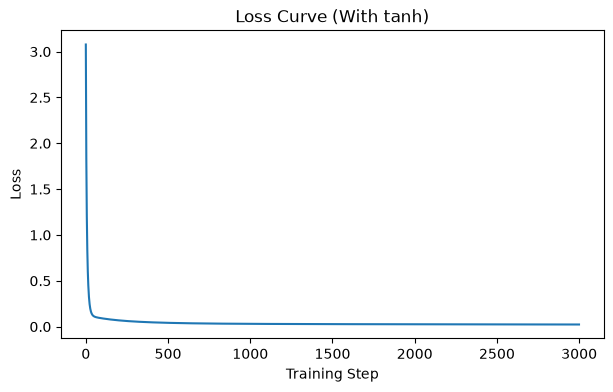

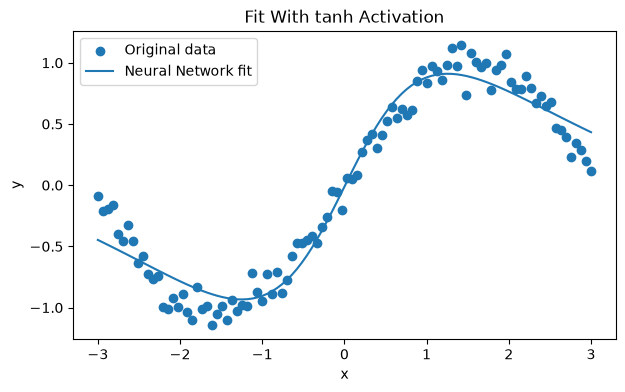

Final loss without tanh: 0.19545179713962046


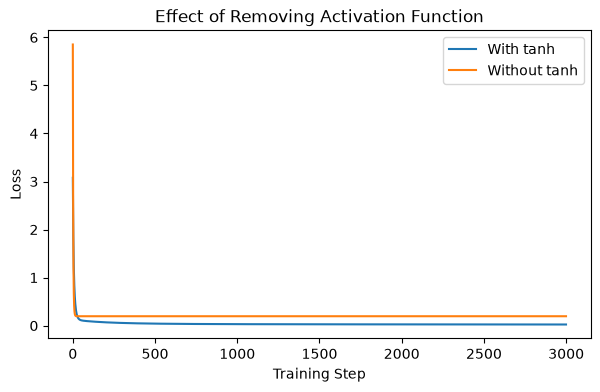

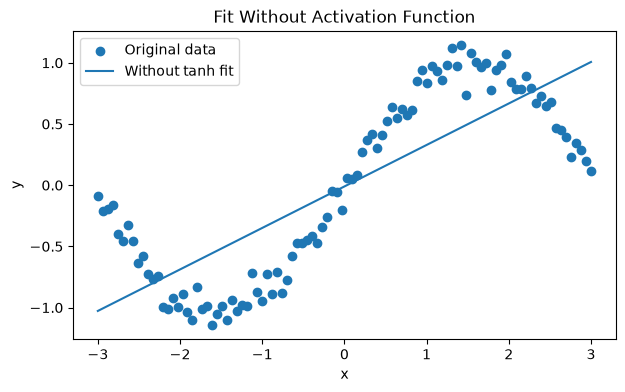

In [9]:
import numpy as np
import matplotlib.pyplot as plt


# Ensure correct data shape


x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

print("x shape:", x.shape)
print("y shape:", y.shape)



# Part 1.2: Hidden layers and activations
# 1 input - 8 hidden neurons - 1 output



# Initialise parameters
np.random.seed(42)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)

W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)

lr = 0.01
losses = []



# Training with tanh activation

for step in range(3000):

    # Forward pass
    z1 = x @ W1 + b1
    h = np.tanh(z1)

    y_hat = h @ W2 + b2

    # Loss
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)


    # Backward pass
    d_yhat = 2 * (y_hat - y) / len(y)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2.T

    # tanh derivative
    dz1 = dh * (1 - h**2)

    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)


    # Update parameters
    W1 -= lr * dW1
    b1 -= lr * db1

    W2 -= lr * dW2
    b2 -= lr * db2


print("Final loss with tanh:", losses[-1])



# Plot loss curve


plt.figure(figsize=(7,4))
plt.plot(losses)
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Loss Curve (With tanh)")
plt.show()



# Plot final fit with tanh

z1 = x @ W1 + b1
h = np.tanh(z1)
y_hat = h @ W2 + b2


plt.figure(figsize=(7,4))
plt.scatter(x, y, label="Original data")
plt.plot(x, y_hat, label="Neural Network fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Fit With tanh Activation")
plt.legend()
plt.show()




# Train again without tanh


np.random.seed(42)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)

W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)

losses_linear = []


for step in range(3000):

    # Forward pass without activation
    z1 = x @ W1 + b1
    h = z1

    y_hat = h @ W2 + b2


    # Loss
    loss = np.mean((y_hat - y) ** 2)
    losses_linear.append(loss)


    # Backward pass
    d_yhat = 2 * (y_hat - y) / len(y)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2.T

    # derivative of linear activation = 1
    dz1 = dh

    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)


    # Update parameters
    W1 -= lr * dW1
    b1 -= lr * db1

    W2 -= lr * dW2
    b2 -= lr * db2


print("Final loss without tanh:", losses_linear[-1])



# Compare losses


plt.figure(figsize=(7,4))
plt.plot(losses, label="With tanh")
plt.plot(losses_linear, label="Without tanh")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Effect of Removing Activation Function")
plt.legend()
plt.show()




# Final fit without tanh


z1 = x @ W1 + b1
y_hat_linear = z1 @ W2 + b2


plt.figure(figsize=(7,4))
plt.scatter(x, y, label="Original data")
plt.plot(x, y_hat_linear, label="Without tanh fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Fit Without Activation Function")
plt.legend()
plt.show()

1. When the activation function is removed, every layer becomes a linear transformation. Therefore, the network cannot learn more complex curves than the single neuron model. For example, the network becomes:

y= (xW, + b,) W + b
y= xW,W + b,W + b

Since W,W and b,W + b are just new weights and biases, the whole network can be rewritten as:
y=xW+b

2. The 8 hidden neurons act as different feature detectors. Each neuron changes the input x into a different nonlinear feature through the tanh activation.

3. Backpropagation is the process of calculating how much each network parameter contributed to the error by applying chain rule from the output layer backward, allowing the weights and biases to be updated to reduce the loss.

C:\Users\marfo\AppData\Local\Temp\ipykernel_7020\2797744031.py:31: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y)**2)
C:\Users\marfo\AppData\Local\Temp\ipykernel_7020\2797744031.py:41: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
C:\Users\marfo\AppData\Local\Temp\ipykernel_7020\2797744031.py:43: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - h**2)


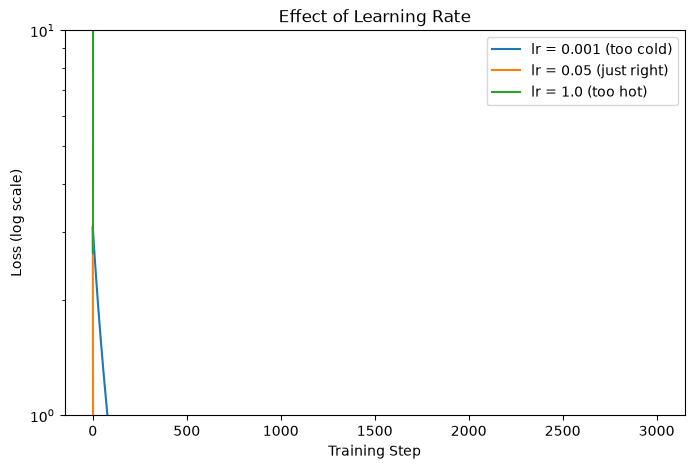

In [12]:
import numpy as np
import matplotlib.pyplot as plt



# Training function
def train_toy(lr, steps=3000):

    # Reset weights for fair comparison
    np.random.seed(42)

    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros(8)

    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros(1)

    losses = []


    for step in range(steps):

        # Forward pass
        z1 = x @ W1 + b1
        h = np.tanh(z1)

        y_hat = h @ W2 + b2


        # Loss
        loss = np.mean((y_hat - y)**2)
        losses.append(loss)


        # Backward pass
        d_yhat = 2 * (y_hat - y) / len(y)

        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)

        dh = d_yhat @ W2.T

        dz1 = dh * (1 - h**2)

        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)


        # Update parameters
        W1 -= lr * dW1
        b1 -= lr * db1

        W2 -= lr * dW2
        b2 -= lr * db2


    return losses




# Train with different learning rates
loss_cold = train_toy(lr=0.001, steps=3000)
loss_good = train_toy(lr=0.05, steps=3000)
loss_hot = train_toy(lr=1.0, steps=3000)




# Plot comparison
plt.figure(figsize=(8,5))

plt.plot(loss_cold, label="lr = 0.001 (too cold)")
plt.plot(loss_good, label="lr = 0.05 (just right)")
plt.plot(loss_hot, label="lr = 1.0 (too hot)")

plt.yscale("log")

plt.xlabel("Training Step")
plt.ylabel("Loss (log scale)")
plt.title("Effect of Learning Rate")
plt.legend()
plt.show()

A very small learning rate makes learning slow bacause the weights modify by small amounts, making the loss to decrease eventually. 
An appropriate learning rate (0.05) allows the model to learn efficiently because updates are big enough to minimize the loss without overshooting.
A very large learning rate causes the loss to explode because the weight updates become too big and repeatedly shoot over the best values instead of moving toward them.